# GEPA sweeps (3 seeds) vs. baselines

Summary of the GEPA sweeps against the canonical empty-prompt baselines: `initial_sweep`
(2026-08-25/26, seed s0 = GepaConfig defaults) plus `second_sweep` (2026-08-27, seed arms
s1/s2 with all seeded parts distinct — rng, mode assignment, pareto fold, minibatch draws).
All numbers are on the canonical **test split** (n=4464: all 3 datasets × all 9 modes).

**GEPA bars show the best of the 3 seeds** (selected by test strict compliance), because the
question is *elicitation*: what controllability a simple optimized prompt can reach, i.e. an
existence proof, for which best-of-N is the right statistic. The mean would mix in GEPA
optimizer variance and understate the elicitation gap. Small dots show all 3 individual seeds
(spread is large — up to ~2× within a cell). Selection-on-test inflation is negligible: test
SE ≈ 0.007 at n=4464, so max-of-3 inflates by ≲0.01.

- **Baseline**: empty system prompt (`baselines/<model>/baseline_results.json`), single run
- **GEPA (free-form)**: prompt optimized with unconstrained reflection, best of 3 seeds
- **GEPA (general-advice)**: prompt constrained to general advice only, best of 3 seeds

† `qwen3-32b` free-form is degenerate in **all 3 seeds**: it reaches ~0.5 strict compliance via
(near-)empty reasoning traces, which strict graders count as compliant for absence-constraints
(s0/s1 mean ≈ 0 words; s2 emits empty traces on 88% of rollouts).

Note: the original sweep's eighth model was `stealth/ox-alpha`, retired from OpenRouter
mid-project and deanonymized as GLM-5.3 Flash. The released checkpoint is not
serving-identical (baseline strict 0.044 → 0.025), so its baseline and both GEPA arms were
re-run (2026-08-27) under `z-ai/glm-5.3-flash` as `glm53flash`; the ox-alpha runs were deleted
(original-serving rollouts survive in `gepa/analysis/length_compliance_cache.oxalpha-orig.parquet`).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().resolve()
if REPO.name == "gepa":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from utils import PALETTE, set_matplotlib_style

set_matplotlib_style()

In [2]:
# (dir key, display name) — sorted by best non-degenerate GEPA strict compliance (best of 3 seeds)
MODELS = [
    ("kimik3", "Kimi-K3"),
    ("gptoss20b", "GPT-OSS-20B"),
    ("gptoss120b", "GPT-OSS-120B"),
    ("glm53", "GLM-5.3"),
    ("dsv4pro", "DeepSeek-V4-Pro"),
    ("qwen32b", "Qwen3-32B"),
    ("glm53flash", "GLM-5.3-Flash"),
    ("qwen8b", "Qwen3-8B"),
]
DEGENERATE = {("qwen32b", "free")}  # all 3 seeds: (near-)empty traces game the strict grader

SEEDS = ["s0", "s1", "s2"]  # s0 = initial_sweep (default seeds), s1/s2 = second_sweep


def run_dir(key, arm, seed):
    return (REPO / "gepa/runs/initial_sweep" / f"{key}_{arm}" if seed == "s0"
            else REPO / "gepa/runs/second_sweep" / f"{key}_{arm}_{seed}")


def overall(path):
    with open(path) as f:
        return json.load(f)["overall"]


# Per-rollout cache over all runs (rebuild with gepa/analysis/extract_length_compliance.py).
import pandas as pd

cache = pd.read_parquet(REPO / "gepa/analysis/length_compliance_cache.parquet")
words_by_run = cache.groupby(["model", "arm", "seed"])["reasoning_words"].mean()

rows = []
for key, name in MODELS:
    row = {"key": key, "name": name}
    row["baseline_strict_compliance"] = overall(
        REPO / "baselines" / key / "baseline_results.json")["strict_compliance"]
    row["baseline_reasoning_words"] = words_by_run[key, "baseline", "-"]
    for arm in ("free", "general"):
        strict = {s: overall(run_dir(key, arm, s) / "test_results.json")["strict_compliance"]
                  for s in SEEDS}
        best = max(strict, key=strict.get)
        row[f"{arm}_best_seed"] = best
        row[f"{arm}_strict_compliance"] = strict[best]
        row[f"{arm}_reasoning_words"] = words_by_run[key, arm, best]
        row[f"{arm}_seeds_strict_compliance"] = strict
        row[f"{arm}_seeds_reasoning_words"] = {s: words_by_run[key, arm, s] for s in SEEDS}
    rows.append(row)

for r in rows:
    fs, gs = r["free_seeds_strict_compliance"], r["general_seeds_strict_compliance"]
    print(f"{r['name']:<16} strict {r['baseline_strict_compliance']:.3f} → "
          f"free {r['free_strict_compliance']:.3f} [{r['free_best_seed']}] "
          f"({'/'.join(f'{fs[s]:.3f}' for s in SEEDS)}) / "
          f"general {r['general_strict_compliance']:.3f} [{r['general_best_seed']}] "
          f"({'/'.join(f'{gs[s]:.3f}' for s in SEEDS)})")

Kimi-K3          strict 0.049 → free 0.688 [s1] (0.387/0.688/0.614) / general 0.572 [s2] (0.455/0.449/0.572)
GPT-OSS-20B      strict 0.009 → free 0.345 [s0] (0.345/0.083/0.137) / general 0.168 [s1] (0.110/0.168/0.098)
GPT-OSS-120B     strict 0.042 → free 0.258 [s1] (0.204/0.258/0.178) / general 0.209 [s1] (0.183/0.209/0.183)
GLM-5.3          strict 0.052 → free 0.254 [s2] (0.186/0.123/0.254) / general 0.143 [s0] (0.143/0.077/0.129)
DeepSeek-V4-Pro  strict 0.008 → free 0.174 [s2] (0.120/0.107/0.174) / general 0.139 [s2] (0.115/0.088/0.139)
Qwen3-32B        strict 0.023 → free 0.524 [s1] (0.498/0.524/0.474) / general 0.122 [s1] (0.120/0.122/0.084)
GLM-5.3-Flash    strict 0.025 → free 0.116 [s0] (0.116/0.077/0.097) / general 0.082 [s1] (0.028/0.082/0.062)
Qwen3-8B         strict 0.011 → free 0.036 [s2] (0.003/0.020/0.036) / general 0.010 [s1] (0.004/0.010/0.010)


saved /root/controllability-elicitation/gepa/analysis/gepa_vs_baselines.png


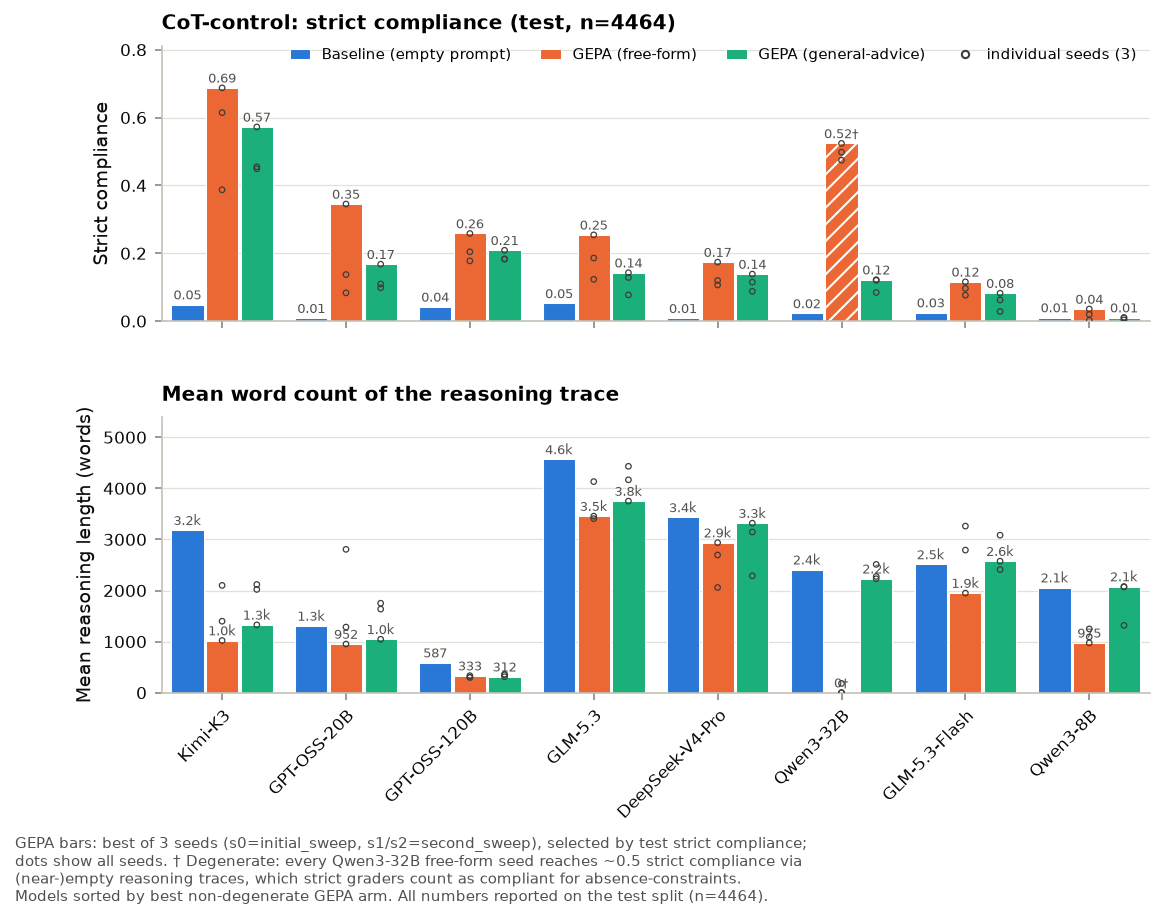

In [3]:
ARMS = [
    ("baseline", "Baseline (empty prompt)", PALETTE[0]),
    ("free", "GEPA (free-form)", PALETTE[1]),
    ("general", "GEPA (general-advice)", PALETTE[2]),
]
fmt_k = lambda v: f"{v / 1000:.1f}k" if v >= 1000 else f"{v:.0f}"
METRICS = [
    ("strict_compliance", "Strict compliance",
     "CoT-control: strict compliance (test, n=4464)", lambda v: f"{v:.2f}"),
    ("reasoning_words", "Mean reasoning length (words)",
     "Mean word count of the reasoning trace", fmt_k),
]

x = np.arange(len(rows))
width = 0.26

fig, axes = plt.subplots(2, 1, figsize=(8.5, 5.6), sharex=True,
                         gridspec_kw={"hspace": 0.35})

for ax, (metric, ylabel, title, fmt) in zip(axes, METRICS):
    for i, (arm, label, color) in enumerate(ARMS):
        vals = [r[f"{arm}_{metric}"] for r in rows]
        offs = x + (i - 1) * (width + 0.02)
        bars = ax.bar(offs, vals, width, label=label, color=color,
                      edgecolor="white", linewidth=0.5)
        labels = []
        for bar, r, v in zip(bars, rows, vals):
            deg = (r["key"], arm) in DEGENERATE
            if deg:
                bar.set_hatch("///")
            labels.append(fmt(v) + ("†" if deg else ""))
        ax.bar_label(bars, labels=labels, fontsize=6.3, color="#52514e", padding=1)
        if arm != "baseline":  # per-seed dots (bar = best of the 3 seeds)
            for xi, r in zip(offs, rows):
                seed_vals = list(r[f"{arm}_seeds_{metric}"].values())
                ax.scatter([xi] * len(seed_vals), seed_vals, s=7, facecolors="none",
                           edgecolors="#3d3d3a", linewidths=0.6, zorder=3)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9.5, pad=8)
    top = max(max(r[f"{arm}_{metric}"] for r in rows for arm, _, _ in ARMS),
              max(v for r in rows for arm in ("free", "general")
                  for v in r[f"{arm}_seeds_{metric}"].values()))
    ax.set_ylim(0, top * 1.18)
    ax.margins(x=0.01)

seed_handle = plt.Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none",
                         markeredgecolor="#3d3d3a", label="individual seeds (3)")
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles + [seed_handle], labels + ["individual seeds (3)"],
               ncols=4, loc="upper right", bbox_to_anchor=(1.0, 1.04), fontsize=7)
axes[1].set_xticks(x, [r["name"] for r in rows], rotation=45, ha="right",
                   rotation_mode="anchor")

fig.text(0.01, -0.06,
         "GEPA bars: best of 3 seeds (s0=initial_sweep, s1/s2=second_sweep), selected by test strict compliance;\n"
         "dots show all seeds. † Degenerate: every Qwen3-32B free-form seed reaches ~0.5 strict compliance via\n"
         "(near-)empty reasoning traces, which strict graders count as compliant for absence-constraints.\n"
         "Models sorted by best non-degenerate GEPA arm. All numbers reported on the test split (n=4464).",
         fontsize=7, color="#52514e", va="top")

out = REPO / "gepa/analysis/gepa_vs_baselines.png"
fig.savefig(out)
print(f"saved {out}")
plt.show()

# Compliance vs. reasoning length: is GEPA just shortening the CoT?

GEPA prompts both raise compliance **and** shorten reasoning traces, and shorter traces are mechanically easier to keep compliant (fewer chances to slip). To disambiguate the two effects, we plot per-rollout strict compliance against reasoning length (log-spaced word-count bins, pooled over modes/datasets), one subplot per model, one line per (arm, seed). If a GEPA curve sits **above baseline at the same length**, the gain is not just a length effect. Length is word count (`len(reasoning.split())`), matching the CoT-Control paper's unit (their §5.3 stratifies compliance by CoT word count).

All 3 GEPA seeds are shown per arm: the **best-of-3 run** (the one the summary-plot bars use) is drawn at full weight with binomial-SE error bars; the other two seeds are thin faded lines in the same arm color. Data: `gepa/analysis/length_compliance_cache.parquet`, built from the per-rollout test-split eval JSONs of all 3 seeds by `gepa/analysis/extract_length_compliance.py` (re-run that script if the cache is missing/stale). Bins with fewer than 50 rollouts are dropped.

**Reading**: for nearly every model, free sits well above baseline across the overlapping length range — in most cells for all 3 seeds, not just the best one — so the compliance gain is *not* explained by shortening alone (Qwen3-8B's GEPA prompts barely help at any length). (The retired original ox-alpha checkpoint had been the one exception where free-arm gains looked mostly length-driven; the released GLM-5.3-Flash checkpoint's free arm sits clearly above baseline at fixed length, so that exception did not survive the re-run — original-serving curves are preserved in `length_compliance_cache.oxalpha-orig.parquet`.)

**Caveats**: (1) bins pool the 9 control modes, so mode composition varies along x and thin bins can be dominated by one easy mode (with char bins this produced a spurious Qwen3-8B baseline spike from an n=57 `meow_between_words`-heavy bin; the word bins used here dilute it away). (2) Length is on-policy, not randomized: models choose when to write short traces, so within-arm slopes are correlational.

saved /root/controllability-elicitation/gepa/analysis/compliance_vs_length.png


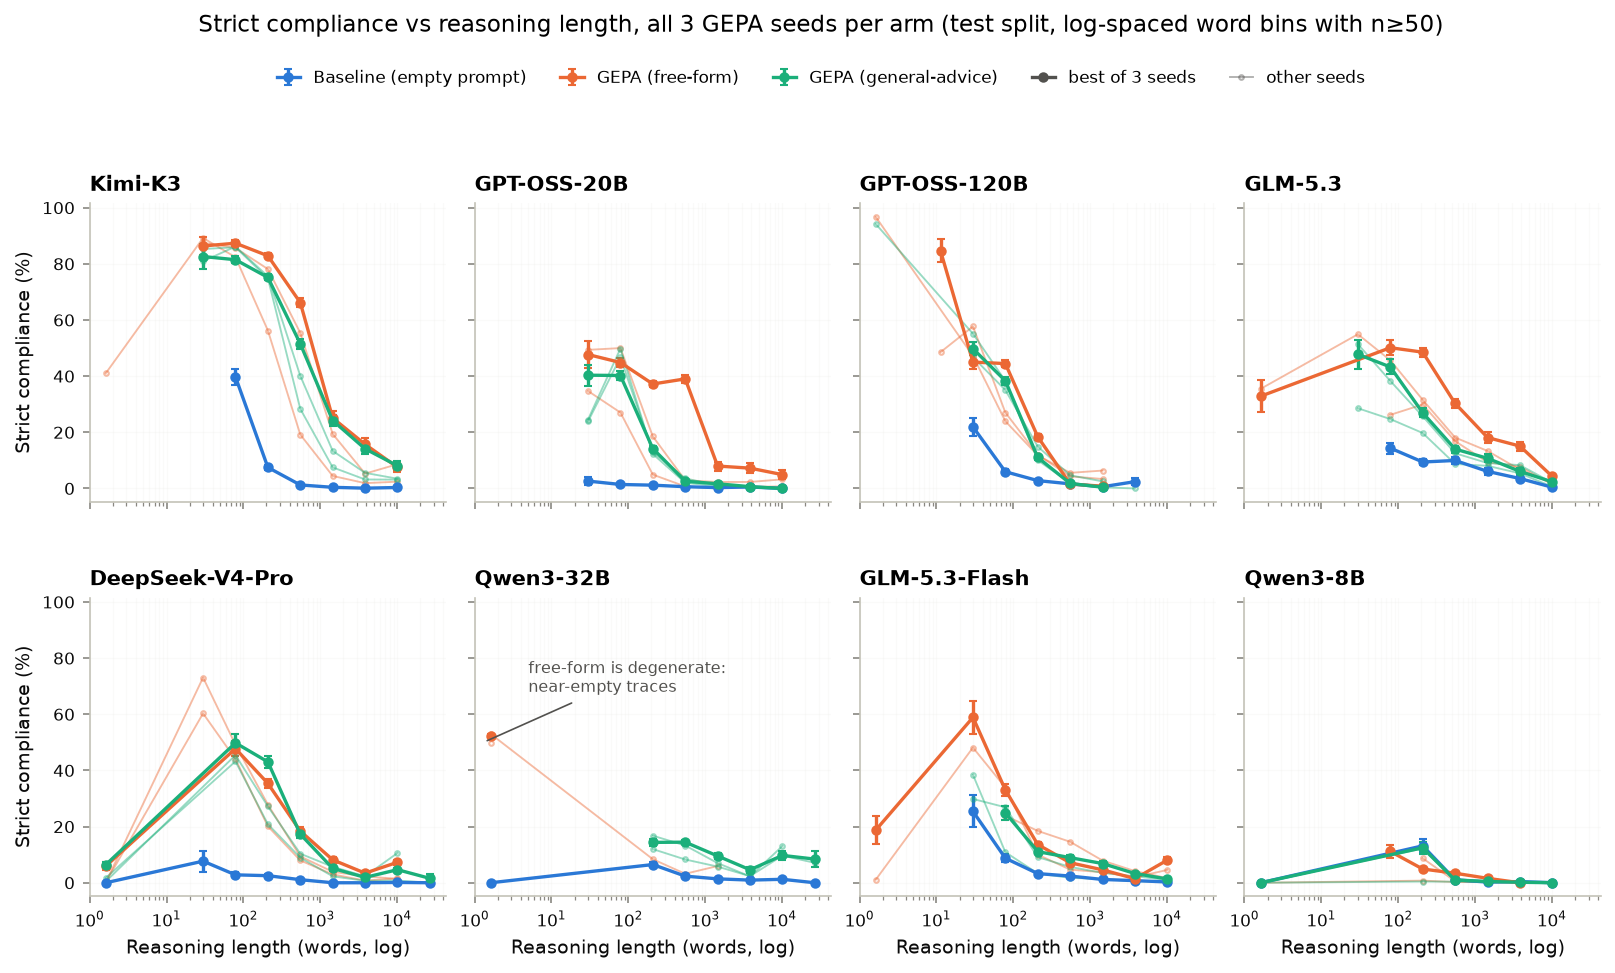

In [4]:
MIN_BIN_N = 50

best_seed = {(r["key"], arm): r[f"{arm}_best_seed"] for r in rows for arm in ("free", "general")}

df = cache.copy()
df["reasoning_words"] = df["reasoning_words"].clip(lower=1)

# Global log-spaced bins so curves are comparable across arms, seeds, and models.
bins = np.geomspace(1, df["reasoning_words"].max() * 1.001, 14)


def binned(sub):
    """(bin geometric center, mean compliance, binomial SE, n) per bin with n >= MIN_BIN_N."""
    idx = np.digitize(sub["reasoning_words"], bins) - 1
    out = []
    for b in range(len(bins) - 1):
        m = idx == b
        n = int(m.sum())
        if n < MIN_BIN_N:
            continue
        p = sub.loc[m, "compliance"].mean()
        out.append((np.sqrt(bins[b] * bins[b + 1]), p, np.sqrt(p * (1 - p) / n), n))
    return np.array(out).reshape(-1, 4)


fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.32, "wspace": 0.08})

for ax, (key, name) in zip(axes.flat, MODELS):
    mdf = df[df["model"] == key]
    for arm, label, color in ARMS:
        adf = mdf[mdf["arm"] == arm]
        for s in (["-"] if arm == "baseline" else SEEDS):
            pts = binned(adf[adf["seed"] == s])
            if not len(pts):
                continue
            cx, p, se, n = pts.T
            if arm == "baseline" or s == best_seed[key, arm]:
                ax.errorbar(cx, 100 * p, yerr=100 * se, color=color, label=label,
                            marker="o", ms=4, lw=1.6, capsize=2)
            else:  # non-best seeds: thin faded lines in the same arm color
                ax.plot(cx, 100 * p, color=color, lw=0.9, alpha=0.45,
                        marker="o", ms=2.2, markerfacecolor="none")
    ax.set_xscale("log")
    ax.set_title(name, fontsize=10)
    ax.grid(True, which="both", alpha=0.15)

# The degenerate qwen32b free-form arms collapse to (near-)empty traces:
# isolated points in the lowest bins.
axes.flat[5].annotate("free-form is degenerate:\nnear-empty traces", xy=(1.3, 50),
                      xytext=(5, 68), fontsize=7.5, color="#52514e",
                      arrowprops=dict(arrowstyle="-", color="#52514e", lw=0.8))

for ax in axes[1]:
    ax.set_xlabel("Reasoning length (words, log)")
for ax in axes[:, 0]:
    ax.set_ylabel("Strict compliance (%)")

handles, labels = axes.flat[0].get_legend_handles_labels()
handles += [plt.Line2D([], [], color="#52514e", lw=1.6, marker="o", ms=4),
            plt.Line2D([], [], color="#52514e", lw=0.9, alpha=0.45, marker="o",
                       ms=2.2, markerfacecolor="none")]
labels += ["best of 3 seeds", "other seeds"]
fig.legend(handles, labels, ncols=5, loc="upper center",
           bbox_to_anchor=(0.5, 1.045), frameon=False)
fig.suptitle("Strict compliance vs reasoning length, all 3 GEPA seeds per arm "
             f"(test split, log-spaced word bins with n≥{MIN_BIN_N})",
             y=1.09, fontsize=11)

out = REPO / "gepa/analysis/compliance_vs_length.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Per-mode breakdown: where does each model gain?

Strict compliance on each of the 9 reasoning-control modes (test split, ~500 rollouts per mode), one subplot per model, three bars per mode (baseline / GEPA free-form / GEPA general-advice). GEPA arms use the **best-of-3-seeds run** selected above (same runs as the summary plot), reading the `per_mode` field of each run's `test_results.json`.

Hatched bars mark the degenerate Qwen3-32B free-form arm (near-empty traces game the strict grader in all 3 seeds, so its per-mode wins are artifacts).

saved /root/controllability-elicitation/gepa/analysis/per_mode_compliance.png


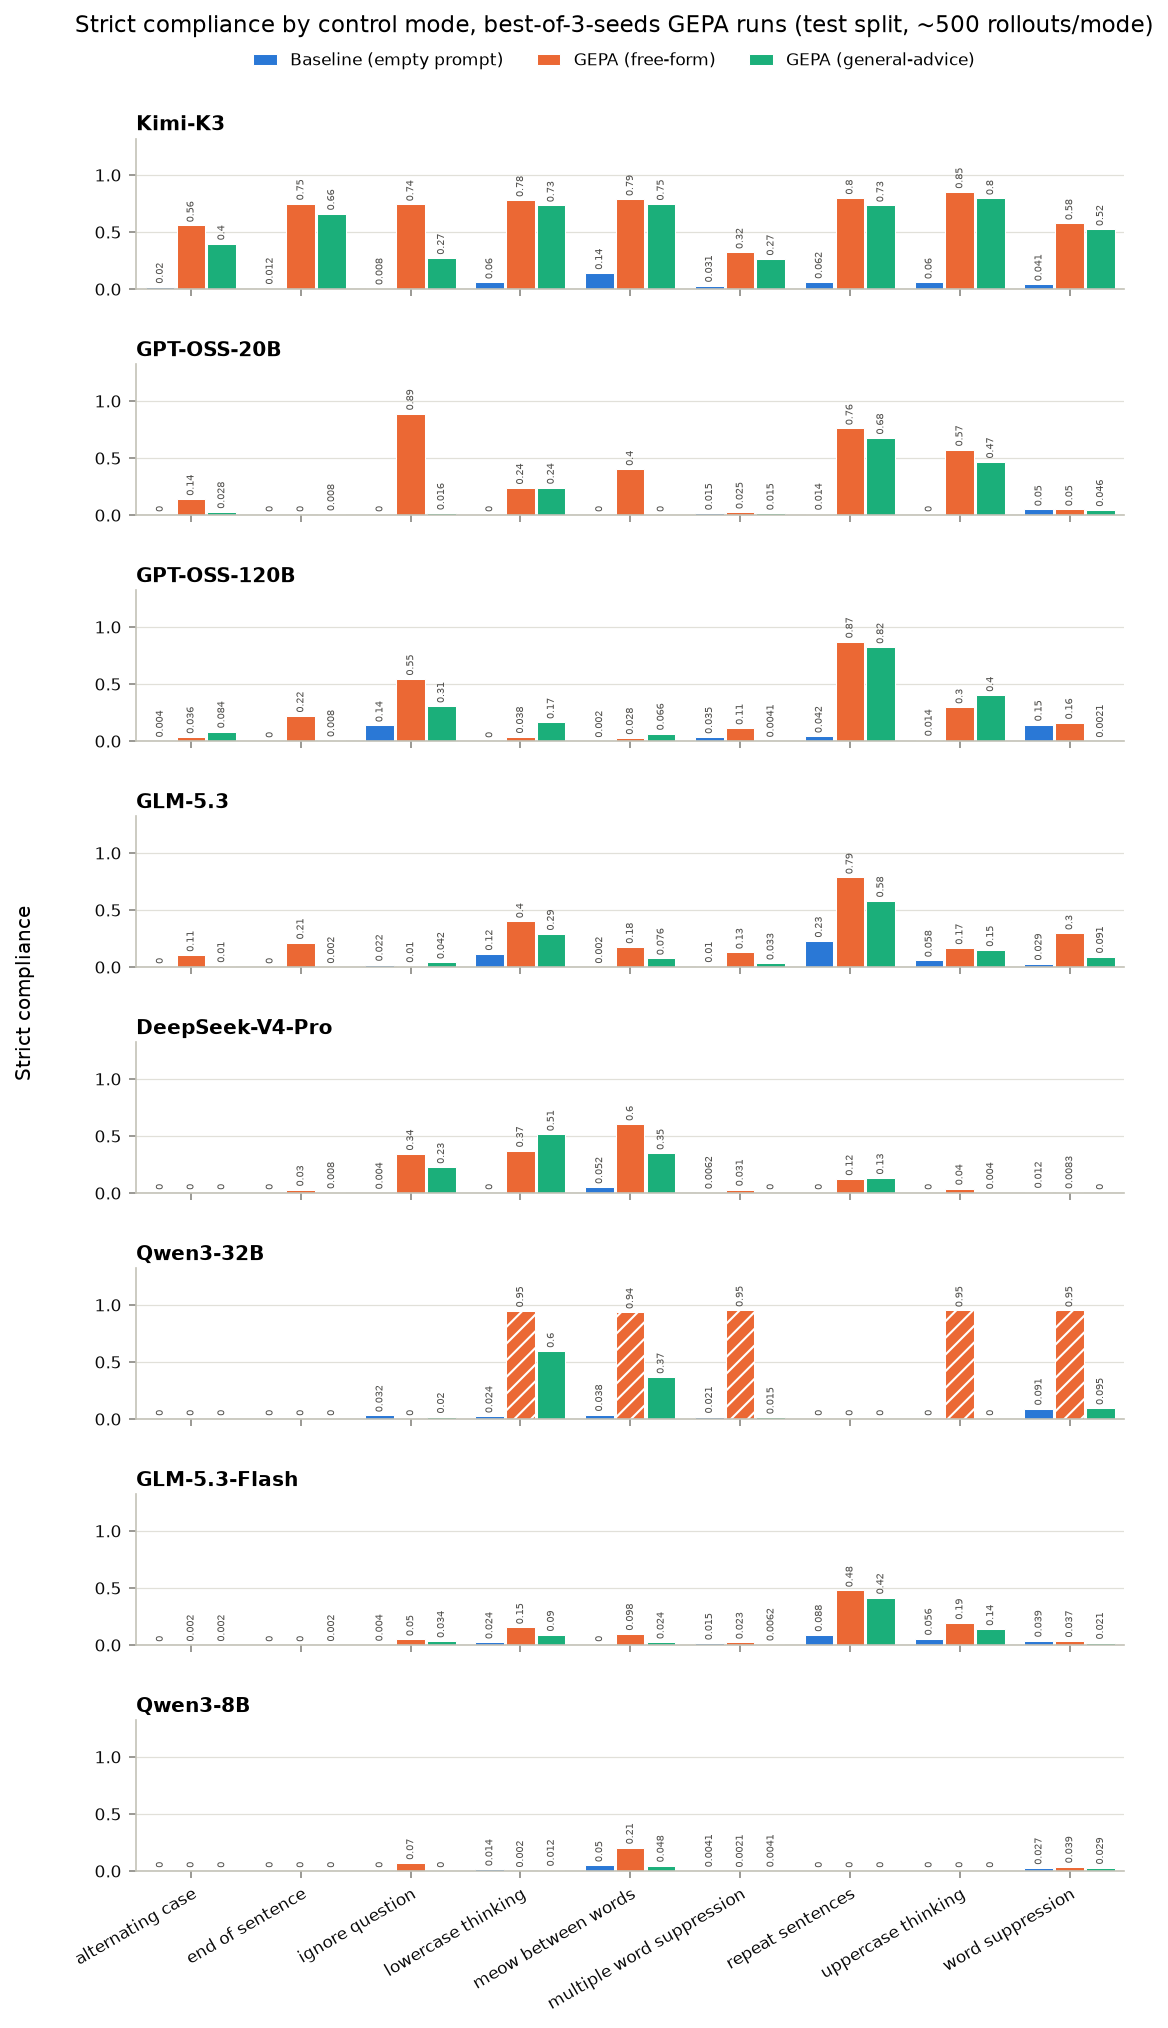

In [5]:
def per_mode_strict(key, arm):
    if arm == "baseline":
        path = REPO / "baselines" / key / "baseline_results.json"
    else:
        best = next(r for r in rows if r["key"] == key)[f"{arm}_best_seed"]
        path = run_dir(key, arm, best) / "test_results.json"
    with open(path) as f:
        return {m: v["strict_compliance"] for m, v in json.load(f)["per_mode"].items()}


per_mode = {(key, arm): per_mode_strict(key, arm)
            for key, _ in MODELS for arm, _, _ in ARMS}
MODES = sorted(per_mode[MODELS[0][0], "baseline"])
assert all(sorted(d) == MODES for d in per_mode.values())

xm = np.arange(len(MODES))
width = 0.26

fig, axes = plt.subplots(len(MODELS), 1, figsize=(8.5, 15), sharex=True, sharey=True,
                         gridspec_kw={"hspace": 0.5})

for ax, (key, name) in zip(axes, MODELS):
    for i, (arm, label, color) in enumerate(ARMS):
        vals = [per_mode[key, arm][m] for m in MODES]
        bars = ax.bar(xm + (i - 1) * (width + 0.02), vals, width, label=label,
                      color=color, edgecolor="white", linewidth=0.5)
        if (key, arm) in DEGENERATE:
            for b in bars:
                b.set_hatch("///")
        ax.bar_label(bars, labels=[f"{v:.2g}" for v in vals], fontsize=5,
                     color="#52514e", rotation=90, padding=1.5)
    ax.set_title(name, fontsize=9.5, pad=4)
    ax.set_ylim(0, 1.32)  # headroom for the rotated bar labels
    ax.set_yticks([0, 0.5, 1])
    ax.margins(x=0.01)

axes[-1].set_xticks(xm, [m.replace("_", " ") for m in MODES], rotation=30,
                    ha="right", rotation_mode="anchor")
fig.supylabel("Strict compliance", fontsize=9.5, x=0.03)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncols=3, loc="upper center",
           bbox_to_anchor=(0.5, 0.925), frameon=False)
fig.suptitle("Strict compliance by control mode, best-of-3-seeds GEPA runs "
             "(test split, ~500 rollouts/mode)", y=0.935, fontsize=11)

out = REPO / "gepa/analysis/per_mode_compliance.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved {out}")
plt.show()

# Transfer to held-out control modes

Do GEPA prompts elicit *general* CoT controllability, or only skill at the 9 training modes? We evaluate every GEPA prompt on the 3 **held-out modes** (`start_of_sentence`, `letter_suppression`, `no_spaces`, added 2026-08-28 from the CoT-Control paper) that were never in the GEPA optimization pool — 500 test questions × 3 modes = 1500 rollouts per run (sweep: `gepa/eval_heldout_modes.py`, rollup in `gepa/runs/heldout_modes_summary.json`; heldout baselines in `baselines/<model>_heldout/`).

**Each GEPA bar is one pre-decided prompt per (model, arm)**: the seed with the highest strict compliance on the *main* test eval — i.e. the prompt you would have shipped *before* ever seeing the held-out modes (the same best-of-3-seeds runs as the summary plot above). Its held-out score is therefore an unbiased transfer measure (no selection on the held-out eval). Dots show all 3 seeds per arm; the hatched † bar is the degenerate Qwen3-32B free-form arm, whose (near-)empty traces trivially satisfy the two absence-type held-out modes.

Kimi-K3          baseline 0.076 → free 0.536 [s1] / general 0.427 [s2]
GPT-OSS-20B      baseline 0.015 → free 0.261 [s0] / general 0.233 [s1]
GPT-OSS-120B     baseline 0.044 → free 0.167 [s1] / general 0.111 [s1]
GLM-5.3          baseline 0.023 → free 0.101 [s2] / general 0.041 [s0]
DeepSeek-V4-Pro  baseline 0.000 → free 0.045 [s2] / general 0.005 [s2]
Qwen3-32B        baseline 0.005 → free 0.315 [s1] / general 0.012 [s1]
GLM-5.3-Flash    baseline 0.014 → free 0.033 [s0] / general 0.043 [s1]
Qwen3-8B         baseline 0.001 → free 0.006 [s2] / general 0.003 [s1]


saved /root/controllability-elicitation/gepa/analysis/gepa_heldout_transfer.png


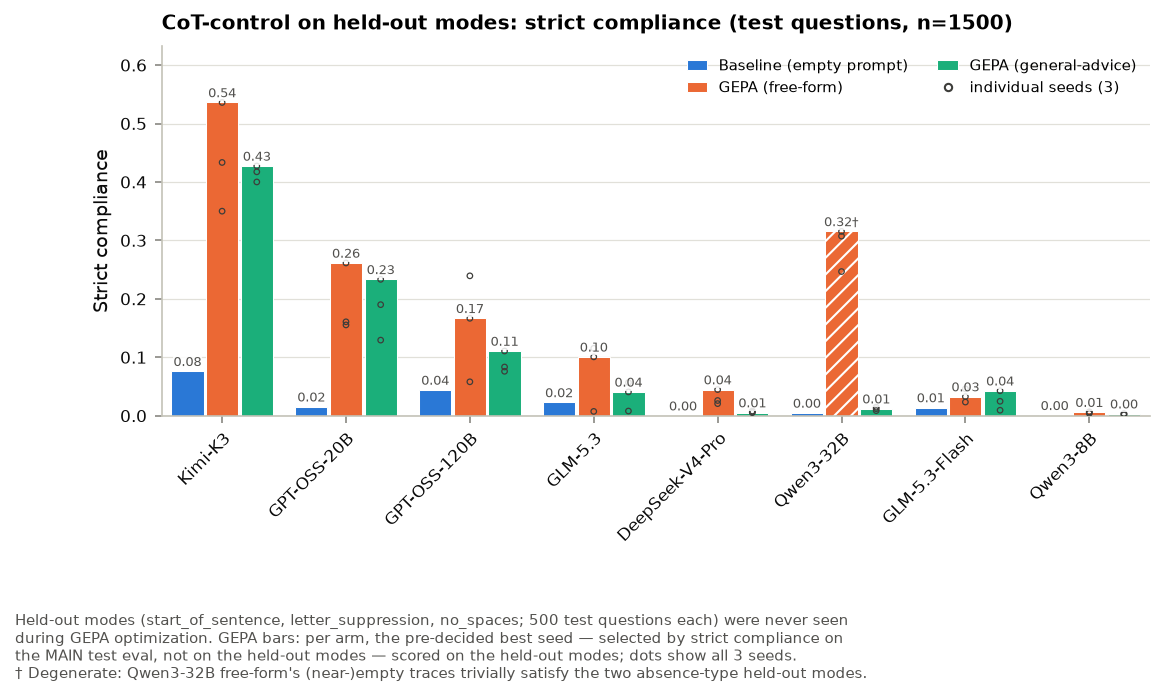

In [6]:
# Transfer to held-out modes (start_of_sentence / letter_suppression / no_spaces),
# which GEPA never optimized against. GEPA bars = per arm, the pre-decided best
# seed (by strict compliance on the MAIN test eval) evaluated on the held-out
# modes; dots = all 3 seeds per arm.
heldout_runs = json.load(open(REPO / "gepa/runs/heldout_modes_summary.json"))["runs"]

def heldout_strict(key, arm, seed):
    rk = f"initial_sweep/{key}_{arm}" if seed == "s0" else f"second_sweep/{key}_{arm}_{seed}"
    return heldout_runs[rk]["overall"]["strict_compliance"]

ho_rows = []
for key, name in MODELS:
    row = {"key": key, "name": name,
           "baseline_heldout": overall(REPO / "baselines" / f"{key}_heldout"
                                       / "baseline_results.json")["strict_compliance"]}
    for arm in ("free", "general"):
        test = {s: overall(run_dir(key, arm, s) / "test_results.json")["strict_compliance"]
                for s in SEEDS}
        best = max(test, key=test.get)  # pre-decided on the MAIN eval, not held-out
        row[f"{arm}_best_seed"] = best
        row[f"{arm}_heldout"] = heldout_strict(key, arm, best)
        row[f"{arm}_seeds_heldout"] = {s: heldout_strict(key, arm, s) for s in SEEDS}
    ho_rows.append(row)

for r in ho_rows:
    print(f"{r['name']:<16} baseline {r['baseline_heldout']:.3f} → "
          f"free {r['free_heldout']:.3f} [{r['free_best_seed']}] / "
          f"general {r['general_heldout']:.3f} [{r['general_best_seed']}]")

x = np.arange(len(ho_rows))
width = 0.26

fig, ax = plt.subplots(figsize=(8.5, 3.2))
for i, (arm, label, color) in enumerate(ARMS):
    vals = [r[f"{arm}_heldout" if arm != "baseline" else "baseline_heldout"] for r in ho_rows]
    offs = x + (i - 1) * (width + 0.02)
    bars = ax.bar(offs, vals, width, label=label, color=color,
                  edgecolor="white", linewidth=0.5)
    labels = []
    for bar, r, v in zip(bars, ho_rows, vals):
        deg = (r["key"], arm) in DEGENERATE
        if deg:
            bar.set_hatch("///")
        labels.append(f"{v:.2f}" + ("†" if deg else ""))
    for t in ax.bar_label(bars, labels=labels, fontsize=6.3, color="#52514e", padding=1,
                          bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.3)):
        t.set_zorder(4)  # above the seed dots (a dot at bar height = the selected seed)
    if arm != "baseline":  # per-seed dots (bar = the main-eval-best seed)
        for xi, r in zip(offs, ho_rows):
            seed_vals = list(r[f"{arm}_seeds_heldout"].values())
            ax.scatter([xi] * len(seed_vals), seed_vals, s=7, facecolors="none",
                       edgecolors="#3d3d3a", linewidths=0.6, zorder=3)

ax.set_ylabel("Strict compliance")
ax.set_title("CoT-control on held-out modes: strict compliance (test questions, n=1500)",
             fontsize=9.5, pad=8)
top = max(max(r["baseline_heldout"], *(v for arm in ("free", "general")
              for v in r[f"{arm}_seeds_heldout"].values())) for r in ho_rows)
ax.set_ylim(0, top * 1.18)
ax.margins(x=0.01)
ax.set_xticks(x, [r["name"] for r in ho_rows], rotation=45, ha="right",
              rotation_mode="anchor")

seed_handle = plt.Line2D([], [], marker="o", ls="none", ms=3.5, markerfacecolor="none",
                         markeredgecolor="#3d3d3a", label="individual seeds (3)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [seed_handle], labels + ["individual seeds (3)"],
          ncols=2, loc="upper right", fontsize=7)

fig.text(0.01, -0.30,
         "Held-out modes (start_of_sentence, letter_suppression, no_spaces; 500 test questions each) were never seen\n"
         "during GEPA optimization. GEPA bars: per arm, the pre-decided best seed — selected by strict compliance on\n"
         "the MAIN test eval, not on the held-out modes — scored on the held-out modes; dots show all 3 seeds.\n"
         "† Degenerate: Qwen3-32B free-form's (near-)empty traces trivially satisfy the two absence-type held-out modes.",
         fontsize=7, color="#52514e", va="top")

out = REPO / "gepa/analysis/gepa_heldout_transfer.png"
fig.savefig(out)
print(f"saved {out}")
plt.show()

# Model scale vs. controllability

Does controllability track model size? Strict compliance (baseline / GEPA free-form / GEPA general-advice) against parameter count, on log-x with an OLS fit in log-params. Unlike the summary plot's best-of-3-seeds (the elicitation statistic), **GEPA points here are the mean of the 3 seeds**: for trend estimation the mean keeps GEPA optimizer noise out of the fit (best-of-3 hands high leverage to single lucky seeds, e.g. GPT-OSS-20B free-form's 0.345 outlier seed). Two panels: **total** and **activated** parameters — the MoE models differ by 15–30× between the two, and across these 8 models the two counts are too collinear to distinguish which one matters. The degenerate Qwen3-32B free-form arm (all 3 seeds; see the summary plot) is excluded from the free-form points, fit, and stats (n=7 for that series).

Parameter counts are public specs: Qwen3-8B/32B dense (8.2B / 32.8B), GPT-OSS-20B/120B (21B-A3.6B / 117B-A5.1B), GLM-5.3-Flash (320B-A18B), GLM-5.3 (743B-A40B, same base as GLM-5.2), DeepSeek-V4-Pro (1.6T-A49B), Kimi-K3 (2.8T-A104B).

**Reading**: correlations are positive but non-significant at n≤8 (vs. log total params: baseline r≈0.53, free r≈0.59, general r≈0.59; p ≈ 0.12–0.33). On seed means, the bigger model in each family is more controllable in every arm (3/3 families), but across labs the training recipe dominates: Kimi-K3 (2.8T) far overperforms the trend in every arm while DeepSeek-V4-Pro (1.6T, lowest baseline compliance of all 8) and GLM-5.3-Flash sit below it.

saved /root/controllability-elicitation/gepa/analysis/scale_vs_controllability.png


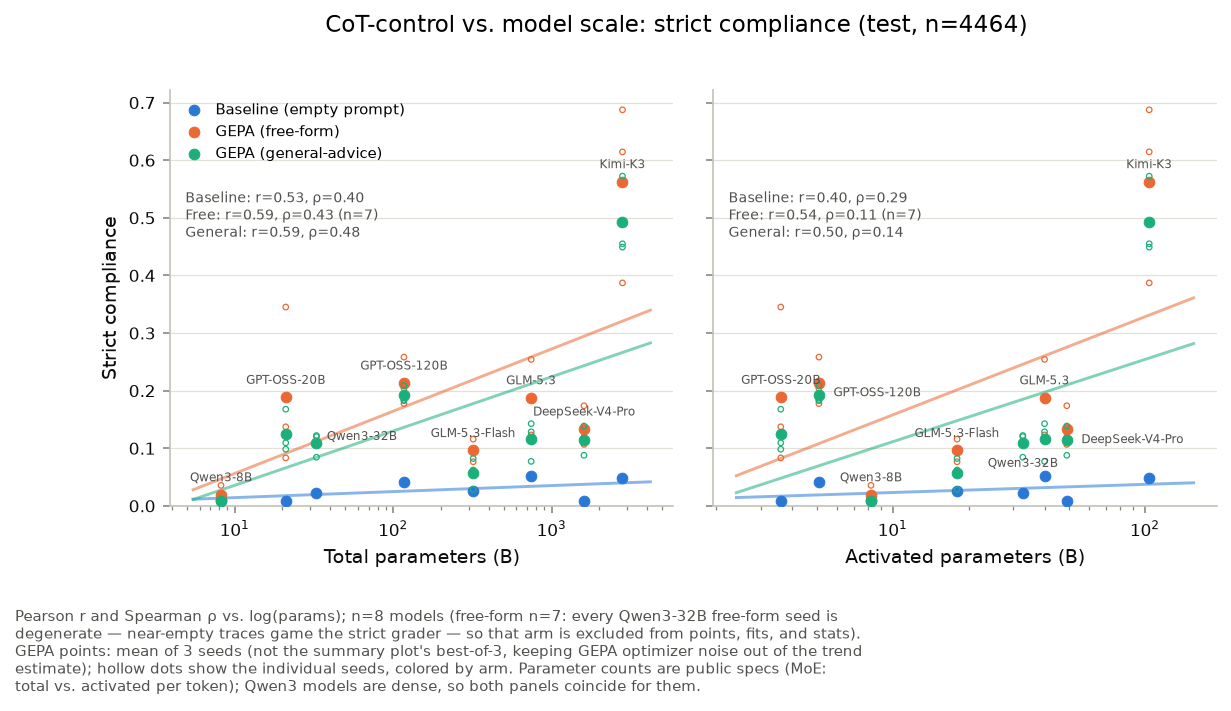

In [7]:
# Public parameter counts (billions): total / activated per token.
# Qwen3 dense (HF model cards); gpt-oss model card; GLM-5.3-Flash 320B-A18B and
# GLM-5.3 = the 743B-A40B GLM-5.2 base (Z.ai); DeepSeek-V4-Pro 1.6T-A49B;
# Kimi-K3 2.8T-A104B (tech report).
PARAMS_B = {  # key: (total, activated)
    "qwen8b": (8.2, 8.2),
    "gptoss20b": (21, 3.6),
    "qwen32b": (32.8, 32.8),
    "gptoss120b": (117, 5.1),
    "glm53flash": (320, 18),
    "glm53": (743, 40),
    "dsv4pro": (1600, 49),
    "kimik3": (2800, 104),
}

SCALE_ARMS = [  # GEPA arms = mean of 3 seeds (less optimizer noise than best-of-3)
    ("Baseline (empty prompt)", "baseline", PALETTE[0]),
    ("GEPA (free-form)", "free", PALETTE[1]),
    ("GEPA (general-advice)", "general", PALETTE[2]),
]

seed_mean = lambda r, arm: np.mean(list(r[f"{arm}_seeds_strict_compliance"].values()))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True,
                         gridspec_kw={"wspace": 0.08})

for ax, pi, xlabel in zip(axes, (0, 1), ("Total parameters (B)",
                                         "Activated parameters (B)")):
    stats = []
    for label, arm, color in SCALE_ARMS:
        # the degenerate qwen32b free arm is dropped from points, fit, and stats
        keep = [r for r in rows if (r["key"], arm) not in DEGENERATE]
        px = np.array([PARAMS_B[r["key"]][pi] for r in keep])
        lx = np.log10(px)
        y = np.array([r["baseline_strict_compliance"] if arm == "baseline"
                      else seed_mean(r, arm) for r in keep])
        ax.scatter(px, y, s=26, color=color, label=label, zorder=3)
        slope, icept = np.polyfit(lx, y, 1)
        gx = np.geomspace(px.min() / 1.5, px.max() * 1.5, 2)
        ax.plot(gx, slope * np.log10(gx) + icept, color=color, lw=1.4,
                alpha=0.55, zorder=2)
        r_p = np.corrcoef(lx, y)[0, 1]
        r_s = pd.Series(lx).corr(pd.Series(y), method="spearman")
        n7 = "" if len(keep) == len(rows) else f" (n={len(keep)})"
        stats.append(f"{arm.capitalize()}: r={r_p:.2f}, ρ={r_s:.2f}{n7}")
        if arm != "baseline":  # per-seed dots (point = mean of the 3 seeds)
            for r in keep:
                xi = PARAMS_B[r["key"]][pi]
                seed_vals = list(r[f"{arm}_seeds_strict_compliance"].values())
                ax.scatter([xi] * len(seed_vals), seed_vals, s=7,
                           facecolors="none", edgecolors=color,
                           linewidths=0.6, zorder=3)
    # direct labels above each model's highest non-degenerate GEPA mean;
    # (dx, dy, ha) overrides de-collide the clusters on each axis
    nudge = ({"qwen32b": (5, 3, "left")} if pi == 0 else
             {"qwen32b": (0, -7, "center"), "dsv4pro": (7, -2, "left"),
              "gptoss120b": (7, -2, "left")})
    for r in rows:
        xi = PARAMS_B[r["key"]][pi]
        ytop = max(seed_mean(r, a) for a in ("free", "general")
                   if (r["key"], a) not in DEGENERATE)
        dx, dy, ha = nudge.get(r["key"], (0, 5, "center"))
        ax.annotate(r["name"], (xi, ytop),
                    textcoords="offset points", xytext=(dx, dy), ha=ha,
                    va="top" if dy < 0 else ("center" if dx else "bottom"),
                    fontsize=5.8, color="#52514e")
    ax.set_xscale("log")
    ax.set_xlabel(xlabel)
    ax.text(0.03, 0.76, "\n".join(stats), transform=ax.transAxes, va="top",
            fontsize=6.8, color="#52514e")

axes[0].set_ylabel("Strict compliance")
axes[0].legend(loc="upper left", fontsize=7)
axes[0].set_ylim(bottom=0)
fig.suptitle("CoT-control vs. model scale: strict compliance (test, n=4464)",
             y=1.02, fontsize=11)

fig.text(0.01, -0.08,
         "Pearson r and Spearman ρ vs. log(params); n=8 models (free-form n=7: every Qwen3-32B free-form seed is\n"
         "degenerate — near-empty traces game the strict grader — so that arm is excluded from points, fits, and stats).\n"
         "GEPA points: mean of 3 seeds (not the summary plot's best-of-3, keeping GEPA optimizer noise out of the trend\n"
         "estimate); hollow dots show the individual seeds, colored by arm. Parameter counts are public specs (MoE:\n"
         "total vs. activated per token); Qwen3 models are dense, so both panels coincide for them.",
         fontsize=7, color="#52514e", va="top")

out = REPO / "gepa/analysis/scale_vs_controllability.png"
fig.savefig(out)
print(f"saved {out}")
plt.show()

# new_models_sweep: 5 additional models (single seed)

Same GEPA recipe as `initial_sweep` (identical BASE_FLAGS, GepaConfig default seeds → comparable
to the s0 arm above), run 2026-08-31 on 5 models not in the original sweep:
`nvidia/nemotron-3-ultra-550b-a55b`, `z-ai/glm-5.2`, `qwen/qwen3.8-27b`, `qwen/qwen3.8-2.4t-a95b`,
`moonshotai/kimi-k2.6`. **One seed per cell** — no best-of-N or seed dots here; given the ~2×
within-cell seed spread above, treat mid-range differences as provisional.

Two caveats vs. the summary plot:

- **Baseline bars are the empty seed prompt scored on the val pareto fold (n=128, mean of the two
  arms' seed evals)** — no test-split baselines exist for these models yet (nothing under
  `baselines/`), so the baseline is on a different split than the GEPA bars. Panel 2 uses
  reasoning **chars** (not words) for the same reason: the baseline number comes from the stored
  `pareto_reasoning_chars`, with no baseline rollouts to count words from.
- **Nemotron-3-Ultra**: the original test evals lost 30–36% of rollouts to provider 429s (both
  4464-rollout evals ran concurrently; its provider pool is capacity-limited). Canonical
  `test_results.json` is the sequential concurrency-50 rerun (`rerun_nemotron_test.py`;
  degraded originals kept as `test_results_429degraded.json`). The reruns still lost 2.6–6% of
  rollouts, which count as failures, so its bars remain slightly understated.

**Reading**: Nemotron-3-Ultra (.30 free) and GLM-5.2 (.26 free) land mid-pack, both free > general.
The other three are **null in both arms**: Kimi-K2.6 (controllability in the Kimi family emerged
between K2.6 and K3, not a family trait) and both Qwen3.8 models — including the 2.4T flagship,
the most capable model in any sweep by accuracy (seed .71), the starkest capability↔controllability
decoupling datapoint so far. Panel 2 shows the familiar CoT-shortening for the two responsive
models, while the null models' lengths barely move.

Nemotron-3-Ultra  strict 0.004 → free 0.301 / general 0.202
GLM-5.2           strict 0.078 → free 0.264 / general 0.200
Qwen3.8-27B       strict 0.000 → free 0.006 / general 0.006
Qwen3.8-2.4T      strict 0.000 → free 0.003 / general 0.002
Kimi-K2.6         strict 0.000 → free 0.001 / general 0.001
saved /root/controllability-elicitation/gepa/analysis/gepa_new_models.png


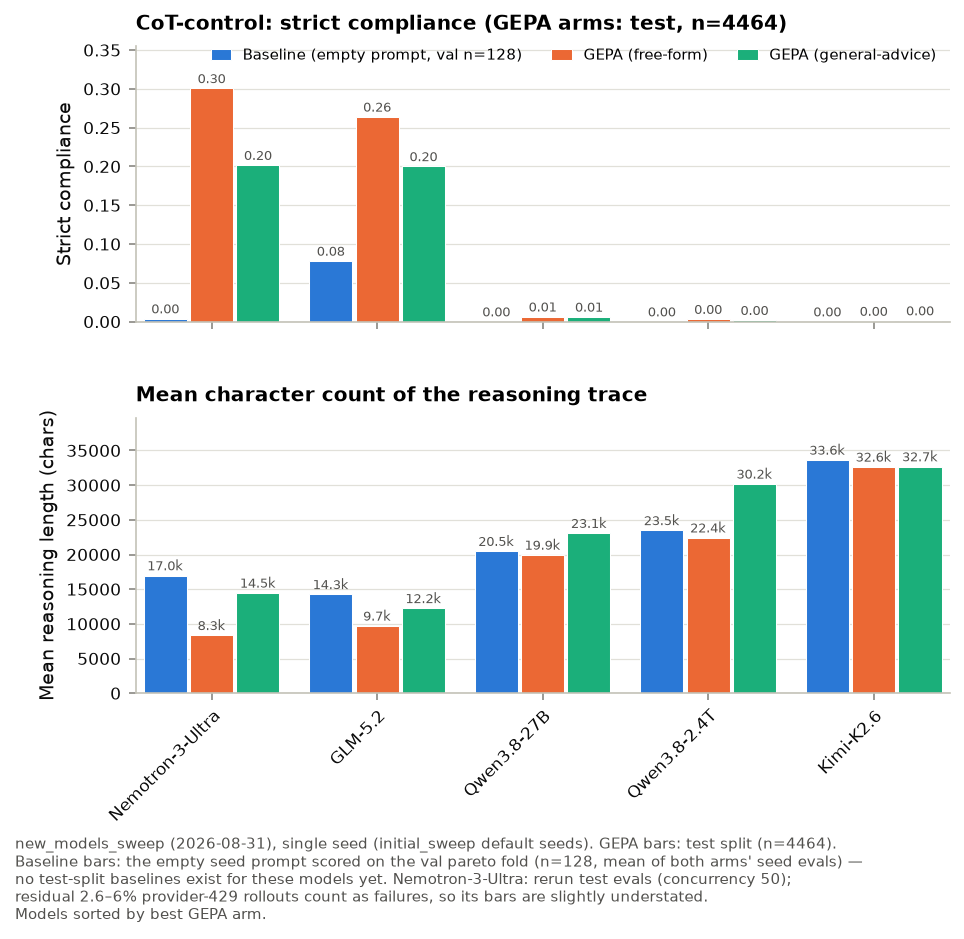

In [8]:
# new_models_sweep (single seed), sorted by best GEPA arm strict compliance
NEW_MODELS = [
    ("nemotron3ultra", "Nemotron-3-Ultra"),
    ("glm52", "GLM-5.2"),
    ("qwen38_27b", "Qwen3.8-27B"),
    ("qwen38_2.4t", "Qwen3.8-2.4T"),
    ("kimik26", "Kimi-K2.6"),
]
NEW_SWEEP = REPO / "gepa/runs/new_models_sweep"


def test_reasoning_chars(run_dir):
    """Mean reasoning chars over non-errored test rollouts (latest eval = canonical)."""
    path = sorted((run_dir / "test_eval").glob("*.json"))[-1]
    with open(path) as f:
        results = json.load(f)["results"]
    lens = [len(s["reasoning"] or "") for r in results for s in r["samples"] if not s["error"]]
    return sum(lens) / len(lens)


def seed_candidate(run_dir):
    with open(run_dir / "candidates.json") as f:
        return json.load(f)[0]


new_rows = []
for key, name in NEW_MODELS:
    row = {"key": key, "name": name}
    # Baseline = empty-prompt seed candidate scored on the val pareto fold
    # (n=128); no test-split baselines exist for these models. Both arms eval
    # the same empty prompt, so average their seed scores.
    seeds = [seed_candidate(NEW_SWEEP / f"{key}_{arm}") for arm in ("free", "general")]
    row["baseline_strict_compliance"] = np.mean([c["pareto_compliance"] for c in seeds])
    row["baseline_reasoning_chars"] = np.mean([c["pareto_reasoning_chars"] for c in seeds])
    for arm in ("free", "general"):
        rd = NEW_SWEEP / f"{key}_{arm}"
        row[f"{arm}_strict_compliance"] = overall(rd / "test_results.json")["strict_compliance"]
        row[f"{arm}_reasoning_chars"] = test_reasoning_chars(rd)
    new_rows.append(row)
    print(f"{name:<17} strict {row['baseline_strict_compliance']:.3f} → "
          f"free {row['free_strict_compliance']:.3f} / "
          f"general {row['general_strict_compliance']:.3f}")

NEW_ARMS = [
    ("baseline", "Baseline (empty prompt, val n=128)", PALETTE[0]),
    ("free", "GEPA (free-form)", PALETTE[1]),
    ("general", "GEPA (general-advice)", PALETTE[2]),
]
NEW_METRICS = [
    ("strict_compliance", "Strict compliance",
     "CoT-control: strict compliance (GEPA arms: test, n=4464)", lambda v: f"{v:.2f}"),
    ("reasoning_chars", "Mean reasoning length (chars)",
     "Mean character count of the reasoning trace", fmt_k),
]

x = np.arange(len(new_rows))
width = 0.26

fig, axes = plt.subplots(2, 1, figsize=(7, 5.6), sharex=True,
                         gridspec_kw={"hspace": 0.35})

for ax, (metric, ylabel, title, fmt) in zip(axes, NEW_METRICS):
    for i, (arm, label, color) in enumerate(NEW_ARMS):
        vals = [r[f"{arm}_{metric}"] for r in new_rows]
        bars = ax.bar(x + (i - 1) * (width + 0.02), vals, width, label=label,
                      color=color, edgecolor="white", linewidth=0.5)
        ax.bar_label(bars, labels=[fmt(v) for v in vals], fontsize=6.3,
                     color="#52514e", padding=1)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9.5, pad=8)
    top = max(r[f"{arm}_{metric}"] for r in new_rows for arm, _, _ in NEW_ARMS)
    ax.set_ylim(0, top * 1.18)
    ax.margins(x=0.01)

axes[0].legend(ncols=3, loc="upper right", bbox_to_anchor=(1.0, 1.04), fontsize=7)
axes[1].set_xticks(x, [r["name"] for r in new_rows], rotation=45, ha="right",
                   rotation_mode="anchor")

fig.text(0.01, -0.06,
    "new_models_sweep (2026-08-31), single seed (initial_sweep default seeds). GEPA bars: test split (n=4464).\n"
    "Baseline bars: the empty seed prompt scored on the val pareto fold (n=128, mean of both arms' seed evals) —\n"
    "no test-split baselines exist for these models yet. Nemotron-3-Ultra: rerun test evals (concurrency 50);\n"
    "residual 2.6–6% provider-429 rollouts count as failures, so its bars are slightly understated.\n"
    "Models sorted by best GEPA arm.",
    fontsize=7, color="#52514e", va="top")

out = REPO / "gepa/analysis/gepa_new_models.png"
fig.savefig(out)
print(f"saved {out}")
plt.show()